In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from core.training import train_tise
from tise1d.tise1d import Loss_PDE, Loss_Orthogonality, PotentialHarmonicOscillator, ansatzfactor_HO_sym

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
torch.manual_seed(124)

In [4]:
# DEFINE DATASET
x_lim = (-5.0, 5.0) # Box

N_samples = 256
x = torch.rand(N_samples, 1)*(x_lim[1]-x_lim[0])+x_lim[0]

In [5]:
from scipy.special import hermite,factorial
import numpy as np

def psi_analytic(x, L = None, n=1):
    hbar = 1
    m = 1
    omega = 1
    x = x.numpy()
    return torch.tensor((1/(np.sqrt((2**n)*factorial(n))*np.pi**0.25))*np.exp(-x**2/2)*hermite(n)(x))

def energy_analytic(L=None,n=1):
    hbar = 1
    omega = 1
    return (n + 0.5)

def compare_analytic(x, pinn, n=1):
    with torch.no_grad():
        psi_pred = pinn(x.to(device)).cpu()
    psi_exact = psi_analytic(x,x[-1], n).cpu()

    overlap = torch.sum(psi_pred*psi_exact) 

    if overlap < 0: 
        psi_pred = -psi_pred

    energy_pred =  pinn.E
    energy_exact = energy_analytic(x[-1], n)
    rel_error = torch.abs((energy_pred - energy_exact) / energy_exact)
    print(f"Predicted Energy: {energy_pred.item():.6f}, Exact Energy: {energy_exact:.6f}, Relative Error: {rel_error:.6%}")
    
    
    plt.plot(x.numpy(), psi_pred.numpy()/torch.sqrt(((x[-1] - x[0])*torch.mean(psi_pred**2))), label='PINN Prediction')
    plt.plot(x.numpy(), psi_exact.numpy(), label='Analytic Solution', linestyle='dashed')
    plt.xlabel('x')
    plt.ylabel('ψ(x)')
    plt.title('Comparison of PINN and Analytic Solution')
    plt.legend()
    plt.show()

In [6]:
pinn1 = train_tise(
    x,
    loss_func = Loss_PDE(PotentialHarmonicOscillator()),
    x_lim=x_lim,
    batch_size = 256,
    lr = 4e-4,
    lr_energy=2e-2,
    E_init = 0.1,
    ansatz_factor=ansatzfactor_HO_sym,
)

Epoch 100/3000. Best loss=2.571e-05. Current loss=2.571e-05. E=0.501315
Epoch 200/3000. Best loss=9.296e-06. Current loss=9.296e-06. E=0.499878
Epoch 300/3000. Best loss=4.661e-06. Current loss=4.661e-06. E=0.499991
Epoch 400/3000. Best loss=2.704e-06. Current loss=2.704e-06. E=0.500040
Epoch 500/3000. Best loss=1.788e-06. Current loss=1.788e-06. E=0.500057
Epoch 600/3000. Best loss=1.264e-06. Current loss=1.264e-06. E=0.500057
Epoch 700/3000. Best loss=9.234e-07. Current loss=9.234e-07. E=0.500048
Epoch 800/3000. Best loss=6.971e-07. Current loss=6.971e-07. E=0.500036
Epoch 900/3000. Best loss=5.482e-07. Current loss=5.482e-07. E=0.500025
Epoch 1000/3000. Best loss=4.503e-07. Current loss=4.503e-07. E=0.500015
Epoch 1100/3000. Best loss=3.844e-07. Current loss=3.844e-07. E=0.500006
Epoch 1200/3000. Best loss=3.378e-07. Current loss=3.378e-07. E=0.499999
Epoch 1300/3000. Best loss=3.032e-07. Current loss=3.032e-07. E=0.499993
Epoch 1400/3000. Best loss=2.762e-07. Current loss=2.762e-07

In [7]:
# Freeze
pinn1.eval()  # freeze behavior
for p in pinn1.parameters():
    p.requires_grad_(False)  

Predicted Energy: 0.499968, Exact Energy: 0.500000, Relative Error: 0.006330%


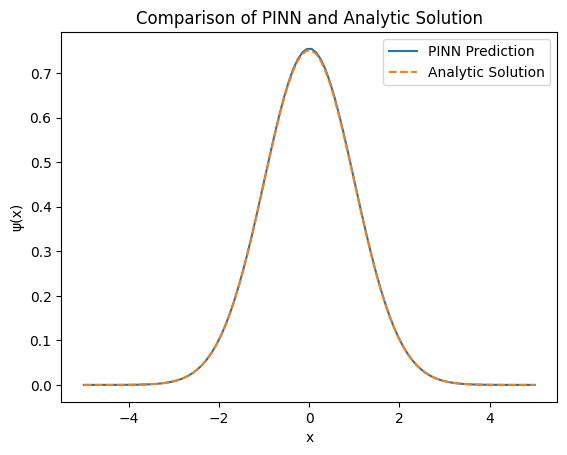

In [8]:
x_test = torch.linspace(x_lim[0], x_lim[1], 100).view(-1, 1).to(device)
compare_analytic(x_test,pinn1,n=0)

In [9]:
pinn2 = train_tise(
    x,
    loss_func = Loss_PDE(PotentialHarmonicOscillator()) + 1.0*Loss_Orthogonality([pinn1]),
    x_lim=x_lim,
    batch_size = 256,
    lr = 4e-4,
    lr_energy=2e-2,
    E_init = 0.5,
    width=16,
    hidden_layers=5,
    ansatz_factor=ansatzfactor_HO_sym,
)

Epoch 100/3000. Best loss=1.469e-02. Current loss=1.469e-02. E=1.527085
Epoch 200/3000. Best loss=6.689e-03. Current loss=6.689e-03. E=1.510003
Epoch 300/3000. Best loss=5.287e-03. Current loss=5.287e-03. E=1.508129
Epoch 400/3000. Best loss=4.517e-03. Current loss=4.517e-03. E=1.506702
Epoch 500/3000. Best loss=4.217e-03. Current loss=4.217e-03. E=1.505673
Epoch 600/3000. Best loss=4.076e-03. Current loss=4.076e-03. E=1.504982
Epoch 700/3000. Best loss=3.962e-03. Current loss=3.962e-03. E=1.504481
Epoch 800/3000. Best loss=3.855e-03. Current loss=3.855e-03. E=1.504054
Epoch 900/3000. Best loss=3.757e-03. Current loss=3.757e-03. E=1.503657
Epoch 1000/3000. Best loss=3.666e-03. Current loss=3.666e-03. E=1.503281
Epoch 1100/3000. Best loss=3.601e-03. Current loss=4.751e-03. E=1.501515
Epoch 1200/3000. Best loss=3.526e-03. Current loss=3.526e-03. E=1.502727
Epoch 1300/3000. Best loss=3.464e-03. Current loss=3.464e-03. E=1.502403
Epoch 1400/3000. Best loss=3.423e-03. Current loss=3.424e-03

In [10]:
# Freeze
pinn2.eval()  # freeze behavior
for p in pinn2.parameters():
    p.requires_grad_(False)

Predicted Energy: 1.500156, Exact Energy: 1.500000, Relative Error: 0.010403%


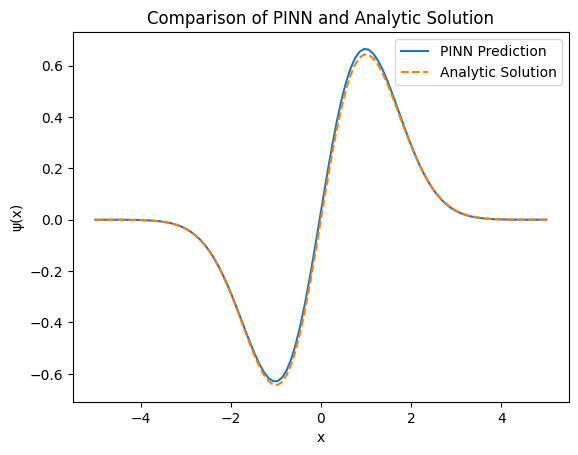

In [11]:
x_test = torch.linspace(x_lim[0], x_lim[1], 100).view(-1, 1).to(device)
compare_analytic(x_test, pinn2,n=1)

In [12]:
pinn3 = train_tise(
x,
loss_func = Loss_PDE(PotentialHarmonicOscillator()) + 4.0*Loss_Orthogonality([pinn1, pinn2]),
x_lim=x_lim,
batch_size = 256,
lr = 4e-4,
lr_energy=2e-2,
E_init = 0.5,
width=16,
hidden_layers=5,
ansatz_factor=ansatzfactor_HO_sym,
)

Epoch 100/3000. Best loss=3.983e+00. Current loss=3.983e+00. E=0.512183
Epoch 200/3000. Best loss=3.982e+00. Current loss=3.982e+00. E=0.513893
Epoch 300/3000. Best loss=3.981e+00. Current loss=3.981e+00. E=0.519240
Epoch 400/3000. Best loss=8.227e-02. Current loss=8.633e-02. E=2.595275
Epoch 500/3000. Best loss=6.791e-02. Current loss=6.791e-02. E=2.534329
Epoch 600/3000. Best loss=6.224e-02. Current loss=6.224e-02. E=2.532711
Epoch 700/3000. Best loss=5.751e-02. Current loss=5.784e-02. E=2.527357
Epoch 800/3000. Best loss=5.286e-02. Current loss=5.286e-02. E=2.527016
Epoch 900/3000. Best loss=5.011e-02. Current loss=5.560e-02. E=2.524341
Epoch 1000/3000. Best loss=4.654e-02. Current loss=4.791e-02. E=2.521477
Epoch 1100/3000. Best loss=4.406e-02. Current loss=5.228e-02. E=2.516166
Epoch 1200/3000. Best loss=4.213e-02. Current loss=1.008e-01. E=2.513103
Epoch 1300/3000. Best loss=4.008e-02. Current loss=4.008e-02. E=2.509894
Epoch 1400/3000. Best loss=3.853e-02. Current loss=4.116e-02

Predicted Energy: 2.499285, Exact Energy: 2.500000, Relative Error: 0.028620%


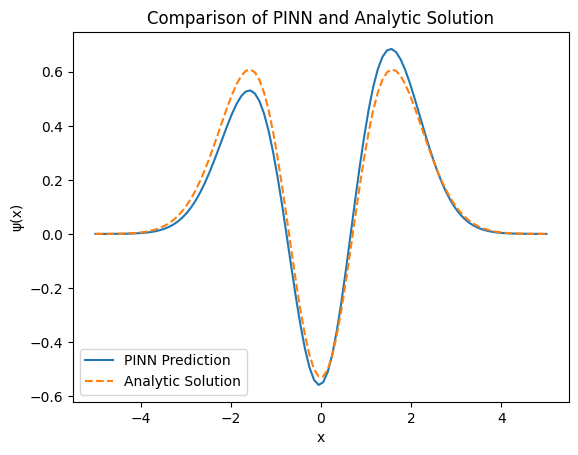

In [13]:
compare_analytic(x_test, pinn3,n=2)

In [ ]:
pinn4 = train_tise(
    x,
    loss_func = Loss_PDE(PotentialHarmonicOscillator()) + 13.0*Loss_Orthogonality([pinn1, pinn2, pinn3]),
    x_lim=x_lim,
    batch_size = 256,
    lr = 4e-4,
    lr_energy=2e-2,
    E_init = 0.5,
    width=16,
    hidden_layers=5,
    ansatz_factor=ansatzfactor_HO_sym,
)

Epoch 100/3000. Best loss=3.416e+00. Current loss=3.709e+00. E=2.682403
Epoch 200/3000. Best loss=7.611e-01. Current loss=7.619e-01. E=3.904601
Epoch 300/3000. Best loss=6.739e-01. Current loss=7.852e-01. E=3.849923
Epoch 400/3000. Best loss=6.087e-01. Current loss=6.844e-01. E=3.817264
Epoch 500/3000. Best loss=5.565e-01. Current loss=6.448e-01. E=3.784742
Epoch 600/3000. Best loss=5.102e-01. Current loss=5.558e-01. E=3.754395
Epoch 700/3000. Best loss=4.859e-01. Current loss=4.978e-01. E=3.741229
Epoch 800/3000. Best loss=4.494e-01. Current loss=4.540e-01. E=3.719873
Epoch 900/3000. Best loss=4.269e-01. Current loss=4.269e-01. E=3.711712
Epoch 1000/3000. Best loss=4.149e-01. Current loss=4.247e-01. E=3.692388
Epoch 1100/3000. Best loss=3.922e-01. Current loss=3.922e-01. E=3.681144
Epoch 1200/3000. Best loss=3.801e-01. Current loss=4.298e-01. E=3.684764
Epoch 1300/3000. Best loss=3.674e-01. Current loss=4.661e-01. E=3.663053
Epoch 1400/3000. Best loss=3.547e-01. Current loss=4.189e-01

Predicted Energy: 3.608269, Exact Energy: 3.500000, Relative Error: 3.093406%


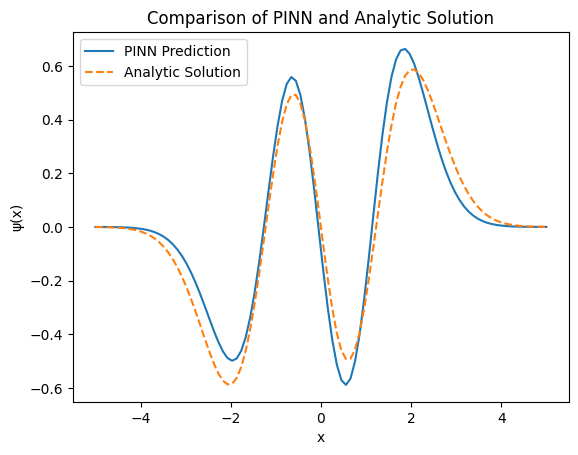

In [15]:
compare_analytic(x_test, pinn4,n=3)

In [19]:
x_test = torch.linspace(x_lim[0], x_lim[1], 100).view(-1, 1).to(device)

learning_rate = np.logspace(np.log10(2e-5),np.log10(2e-3),3)
lr_energy = 2e-2
ortho_loss_weight = 1e2

lambd = 0.0


all_loss_data = np.zeros((len(learning_rate),2))


# Analyze mse vs. learning rate and number of nodes for different numbers of hidden layers and activation functions. 
for i, lr in enumerate(learning_rate):
    print("\n Learning rate: ",lr, end="")
    
    pinn2 = train_tise(
        x,
        loss_func = Loss_PDE(PotentialHarmonicOscillator()) + ortho_loss_weight*Loss_Orthogonality([pinn1]),     # + 500*Loss_Norm()
        x_lim=x_lim,
        hidden_layers = 3,
        width = 64,
        lr = lr,
        lr_energy = lr_energy,
        E_init = 0.5,
        ansatz_factor = ansatzfactor_HO_sym,
        activation_func = nn.Tanh,
        )
    print(".",end="")
    all_loss_data[i] = (
        Loss_PDE(PotentialHarmonicOscillator())(pinn2, x_test).detach().cpu().item(),
        Loss_Orthogonality([pinn1])(pinn2,x_test).detach().cpu().item()
    )



 Learning rate:  2e-05Epoch 100/3000. Best loss=7.139e-02. Current loss=7.139e-02. E=1.523796
Epoch 200/3000. Best loss=7.080e-02. Current loss=7.080e-02. E=1.510014
Epoch 300/3000. Best loss=7.020e-02. Current loss=7.020e-02. E=1.509765
Epoch 400/3000. Best loss=6.958e-02. Current loss=6.958e-02. E=1.509593
Epoch 500/3000. Best loss=6.886e-02. Current loss=6.886e-02. E=1.509399
Epoch 600/3000. Best loss=6.806e-02. Current loss=6.806e-02. E=1.509183
Epoch 700/3000. Best loss=6.719e-02. Current loss=6.719e-02. E=1.508949
Epoch 800/3000. Best loss=6.624e-02. Current loss=6.624e-02. E=1.508699
Epoch 900/3000. Best loss=6.523e-02. Current loss=6.523e-02. E=1.508434
Epoch 1000/3000. Best loss=6.415e-02. Current loss=6.415e-02. E=1.508157
Epoch 1100/3000. Best loss=6.302e-02. Current loss=6.302e-02. E=1.507869
Epoch 1200/3000. Best loss=6.184e-02. Current loss=6.184e-02. E=1.507572
Epoch 1300/3000. Best loss=6.060e-02. Current loss=6.060e-02. E=1.507269
Epoch 1400/3000. Best loss=5.933e-02.

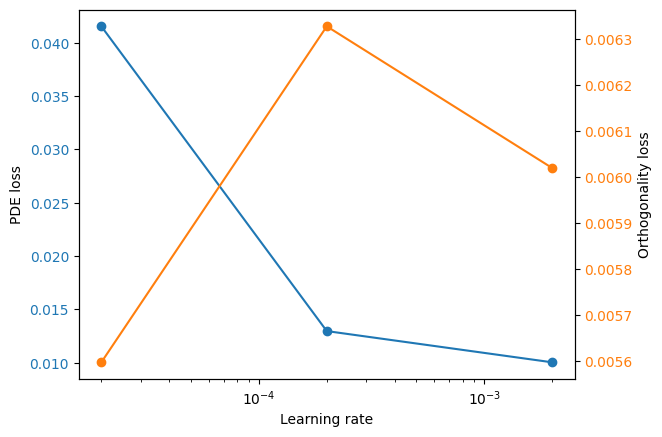

In [ ]:
fig,ax1 = plt.subplots()

ax1.plot(learning_rate,all_loss_data[:,0],"-o",label="Loss PDE", c="C0")
ax1.set_xscale("log")
ax1.set_xlabel("Learning rate")
ax1.set_ylabel("PDE loss")
ax1.tick_params(axis = "y",labelcolor="C0")
ax2 = ax1.twinx()
ax2.plot(learning_rate,all_loss_data[:,1],"-o",label="Loss Orthogonality", c="C1")
ax2.set_ylabel("Orthogonality loss")
ax2.tick_params(axis = "y",labelcolor="C1")


plt.show()

In [ ]:
nodes = np.linspace()
hidden_layers = np.linspace()
activation_funcs = [nn.Tanh,nn.ReLU,nn.Sigmoid]

lambd = 0.0


all_loss_data = np.zeros((len(nodes), len(hidden_layers), len(activation_funcs)))


# Analyze mse vs. learning rate and number of nodes for different numbers of hidden layers and activation functions. 
for i, n_nodes in enumerate(nodes):
    print("\nNode: ",n_nodes, end="")
    for j, n_hidden_layers in enumerate(hidden_layers):
        for k, activation_func in enumerate(activation_funcs):
            
            pinn2 = train_tise(
                loss_func = Loss_PDE(PotentialHarmonicOscillator()) + 4000*Loss_Orthogonality([pinn1]),     # + 500*Loss_Norm()
                x_lim=[-L,L],
                batch_size = 256,
                N_samples = 256,
                hidden_layers = n_hidden_layers,
                width = n_nodes,
                lr = 2e-3,
                E = 0.5,
                ansatz_factor = ansatzfactor_HO_sym,
                activation_func = activation_func,
                )
            print(".",end="")
            all_loss_data[i][j][k] = Loss_PDE(PotentialHarmonicOscillator()) +4000*Loss_Orthogonality([pinn1])